In [1]:
% some housekeeping stuff
%register_graphics_toolkit ("gnuplot");
%available_graphics_toolkits ();
%graphics_toolkit ("plotly")
graphics_toolkit ("notebook")
clear
% end of housekeeping

# simulate first order kinetics



# theory of balls bouncing in a box to simulate first order kinetic process

Consider a box with balls bouncing inside at random.  There is an opening to the box and balls leave through that opening.

![box with bouncing balls](boxforkinetics.png)

The rate that particles leave this box is proportional to the number in the box

$$\dfrac{dN}{dt}\alpha N$$

To convert the proportionality into an equality use the proportionality constant ($k$)

$$\dfrac{dN}{dt}=-kN$$

the negative sign denotes that the particles are leaving the box.  This is a separable differential equation

$$\dfrac{dN}{N}=-kdt$$

To determine the integrated rate law this experession can be integrated on both sides 

$$\int_{N=0}^{N=N}\left( \dfrac{dN}{N}\right) = -k \int_{t=0}^{t=t} dt$$

after completing integration the equation becomes ...

$$\ln{N} = \ln{N_0}-kt$$

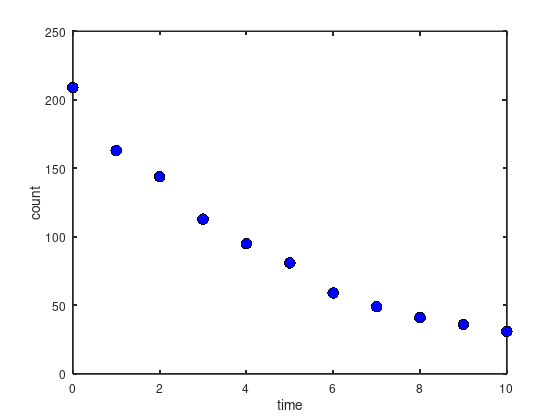

In [2]:
%insert data

data=[...
%time   count
0        83+31+45+50
1         83+31+45+50-17-4-7-18
2         83+31+45+50-17-4-7-18-4-2-7-6
3         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16
4         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4
5         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4-2-3-2-7
6         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4-2-3-2-7-4-2-5-11
7         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4-2-3-2-7-4-2-5-11-1-4-2-3
8         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4-2-3-2-7-4-2-5-11-1-4-2-3-2-2-2-2
9         83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4-2-3-2-7-4-2-5-11-1-4-2-3-2-2-2-2-0-2-1-2
10        83+31+45+50-17-4-7-18-4-2-7-6-5-7-3-16-8-3-3-4-2-3-2-7-4-2-5-11-1-4-2-3-2-2-2-2-0-2-1-2-1-1-3-0
];

time=data(:,1); count=data(:,2);

plot(time,count,'ko','markersize',8,'markerfacecolor','b')
set(gca,'linewidth',1.5,'fontsize',12)
xlabel('time','fontsize',14); ylabel('count','fontsize',14)

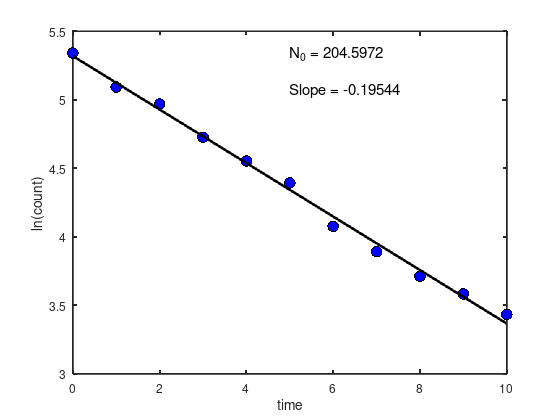

In [3]:
% now linearize the plot and determine rate constant and No

x=time;  y=log(count);

param=polyfit(x,y,1); slope=param(1); intercept=param(2);

fit=slope*time+intercept;

% plot it

plot(x,y,'ko','markersize',8,'markerfacecolor','b')
hold on
plot(x,fit,'k','linewidth',2)

set(gca,'linewidth',1.5,'fontsize',12)
xlabel('time','fontsize',14); ylabel('ln(count)','fontsize',14)

Nostr=num2str(exp(intercept));
slopestr=num2str(slope);

timept=min(time)+0.5*(max(time)-min(time));
%lncountpt=min(y)+0.5*(max(y)-min(y));
lncountpt=max(y);

Noplt=['N_0 = ',Nostr];
text(timept,lncountpt,Noplt,'fontsize',15)
slopeplt=['Slope = ',slopestr];
text(timept,lncountpt-0.05*lncountpt,slopeplt,'fontsize',15)

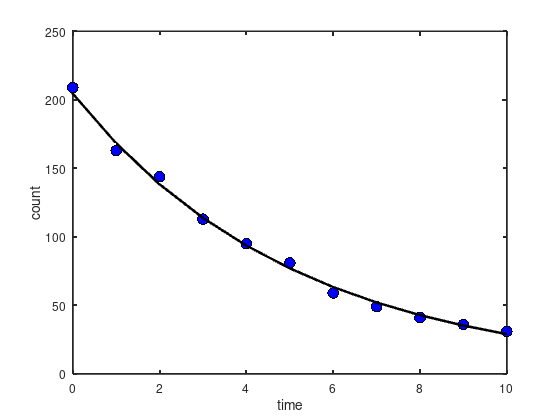

In [4]:
% plot the exponential version

model=exp(intercept)*exp(slope*time);

plot(time,count,'ko','markersize',8,'markerfacecolor','b')
set(gca,'linewidth',1.5,'fontsize',12)
xlabel('time','fontsize',14); ylabel('count','fontsize',14)

hold on
plot(time,model,'k','linewidth',2)

